In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import tree
from sklearn import model_selection
from sklearn import metrics

voice_data = pd.read_csv('voice_gender.csv')

X = voice_data.drop('label', axis=1)
y = voice_data['label']

X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


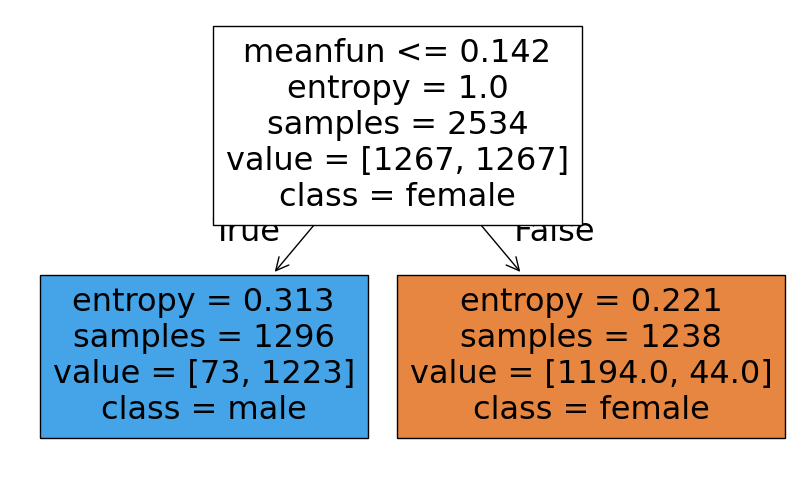

Задание 1:
1. Фактор в корневой вершине: meanfun
2. Оптимальное пороговое значение: 0.142
3. Процент наблюдений, удовлетворяющих условию: 51.1
4. Accuracy на тестовой выборке: 0.956


In [2]:
dt1 = tree.DecisionTreeClassifier(max_depth=1, criterion='entropy')
dt1.fit(X_train, y_train)

plt.figure(figsize=(10, 6))
tree.plot_tree(dt1, feature_names=X.columns, class_names=dt1.classes_, filled=True)
plt.show()

root_feature_idx = dt1.tree_.feature[0]
root_feature_name = X.columns[root_feature_idx]
threshold = dt1.tree_.threshold[0]
samples_left = dt1.tree_.n_node_samples[1]
samples_total = dt1.tree_.n_node_samples[0]

print("Задание 1:")
print("1. Фактор в корневой вершине:", root_feature_name)
print("2. Оптимальное пороговое значение:", round(threshold, 3))
print("3. Процент наблюдений, удовлетворяющих условию:", round(samples_left / samples_total * 100, 1))
print("4. Accuracy на тестовой выборке:", round(metrics.accuracy_score(y_test, dt1.predict(X_test)), 3))

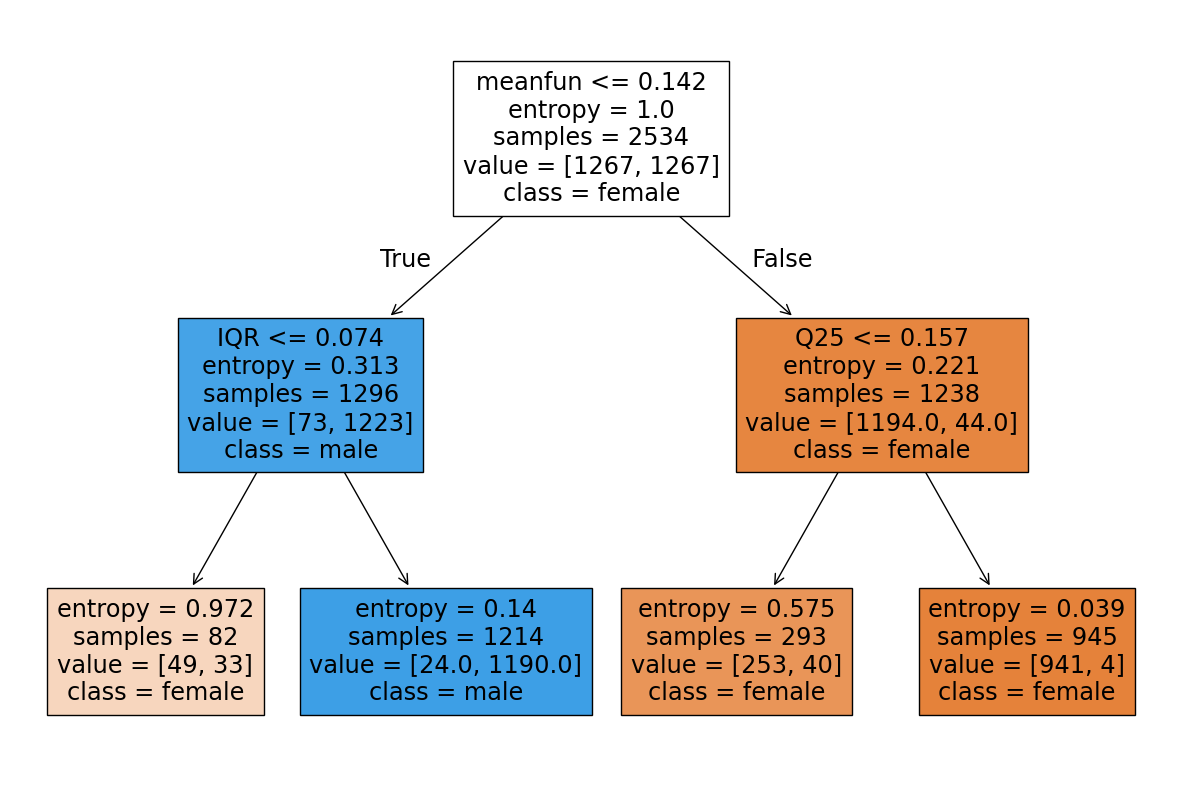

Задание 2:
1. Используемые факторы: ['Q25', 'meanfun', 'IQR']
2. Количество листьев с предсказанием female: 3
3. Accuracy на тестовой выборке: 0.962


In [3]:
dt2 = tree.DecisionTreeClassifier(max_depth=2, criterion='entropy')
dt2.fit(X_train, y_train)

plt.figure(figsize=(15, 10))
tree.plot_tree(dt2, feature_names=X.columns, class_names=dt2.classes_, filled=True)
plt.show()

used_features_idx = set(dt2.tree_.feature[dt2.tree_.feature >= 0])
used_features = [X.columns[i] for i in used_features_idx]

leaves_idx = np.where(dt2.tree_.feature == -2)[0]
female_class_idx = np.where(dt2.classes_ == 'female')[0][0]
female_leaves_count = sum(1 for leaf in leaves_idx if np.argmax(dt2.tree_.value[leaf]) == female_class_idx)

print("Задание 2:")
print("1. Используемые факторы:", used_features)
print("2. Количество листьев с предсказанием female:", female_leaves_count)
print("3. Accuracy на тестовой выборке:", round(metrics.accuracy_score(y_test, dt2.predict(X_test)), 3))

In [4]:
dt3 = tree.DecisionTreeClassifier(criterion='entropy', random_state=0)
dt3.fit(X_train, y_train)

print("Задание 3:")
print("1. Глубина дерева:", dt3.get_depth())
print("2. Количество листьев:", dt3.get_n_leaves())
print("3. Accuracy на обучающей выборке:", round(metrics.accuracy_score(y_train, dt3.predict(X_train)), 3))
print("3. Accuracy на тестовой выборке:", round(metrics.accuracy_score(y_test, dt3.predict(X_test)), 3))

Задание 3:
1. Глубина дерева: 12
2. Количество листьев: 54
3. Accuracy на обучающей выборке: 1.0
3. Accuracy на тестовой выборке: 0.973


In [5]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [4, 5, 6, 7, 8, 9, 10],
    'min_samples_split': [3, 4, 5, 10]
}

cv = model_selection.StratifiedKFold(n_splits=5)

grid_search = model_selection.GridSearchCV(
    estimator=tree.DecisionTreeClassifier(random_state=0),
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print("Задание 4:")
print("1. Наилучший критерий информативности:", best_model.criterion)
print("2. Оптимальная максимальная глубина:", best_model.max_depth)
print("3. Оптимальное min_samples_split:", best_model.min_samples_split)
print("4. Accuracy на обучающей выборке:", round(metrics.accuracy_score(y_train, best_model.predict(X_train)), 3))
print("4. Accuracy на тестовой выборке:", round(metrics.accuracy_score(y_test, best_model.predict(X_test)), 3))

Задание 4:
1. Наилучший критерий информативности: gini
2. Оптимальная максимальная глубина: 7
3. Оптимальное min_samples_split: 3
4. Accuracy на обучающей выборке: 0.996
4. Accuracy на тестовой выборке: 0.97


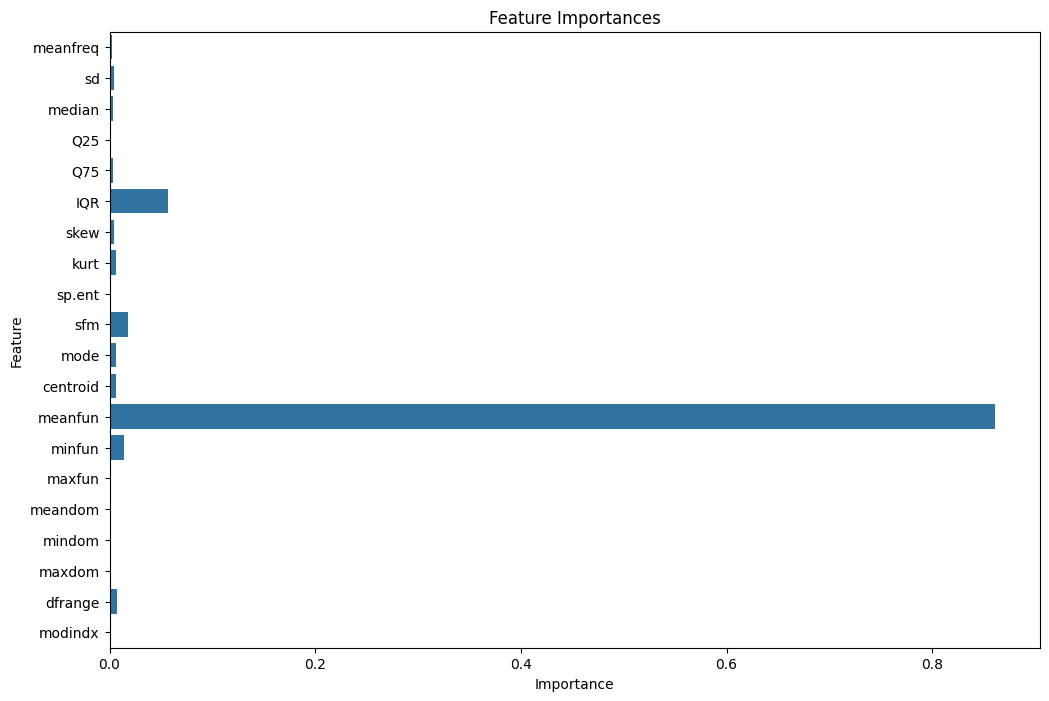

Задание 5:
Топ-3 наиболее важных фактора: ['meanfun', 'IQR', 'sfm']


In [6]:
importances = best_model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(12, 8))
sns.barplot(x=importances, y=feature_names)
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

top_3_idx = np.argsort(importances)[::-1][:3]
top_3_features = [feature_names[i] for i in top_3_idx]

print("Задание 5:")
print("Топ-3 наиболее важных фактора:", top_3_features)